# 🤖 Day 3: AI Workshop - Machine Learning | Supervised & Unsupervised Learning

---
**Topics:**
- What is Machine Learning?
- Types of ML
- ML Workflow
- Introduction to Scikit-learn
- Hands-on: Simple Linear Regression
- Classification Algorithms (Logistic Regression / KNN)
- Clustering (K-Means)
- Train-test split
- Feature selection basics
---

# 📦 Step 0: Install & Import Libraries

In [1]:
# All libraries come pre-installed in Google Colab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix,
    classification_report
)

# Settings
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')
np.random.seed(42)

print('✅ All libraries imported successfully!')
print(f'  NumPy version    : {np.__version__}')
print(f'  Pandas version   : {pd.__version__}')
import sklearn
print(f'  Sklearn version  : {sklearn.__version__}')

✅ All libraries imported successfully!
  NumPy version    : 2.0.2
  Pandas version   : 2.2.2
  Sklearn version  : 1.6.1


---
# 📅 Introduction to Machine Learning
---

## 🧠 1. What is Machine Learning?

> **Machine Learning** is a subset of Artificial Intelligence that enables systems to **learn from data** and improve their performance on tasks **without being explicitly programmed**.

### Key Idea:
- Traditional Programming: `Data + Rules → Output`
- Machine Learning:        `Data + Output → Rules (Model)`

### Real-world examples:
| Application | ML Task |
|---|---|
| Email spam filter | Classification |
| House price prediction | Regression |
| Customer segmentation | Clustering |
| Netflix recommendations | Recommendation System |
| Face recognition | Classification / Deep Learning |

## 🗂️ 2. Types of Machine Learning

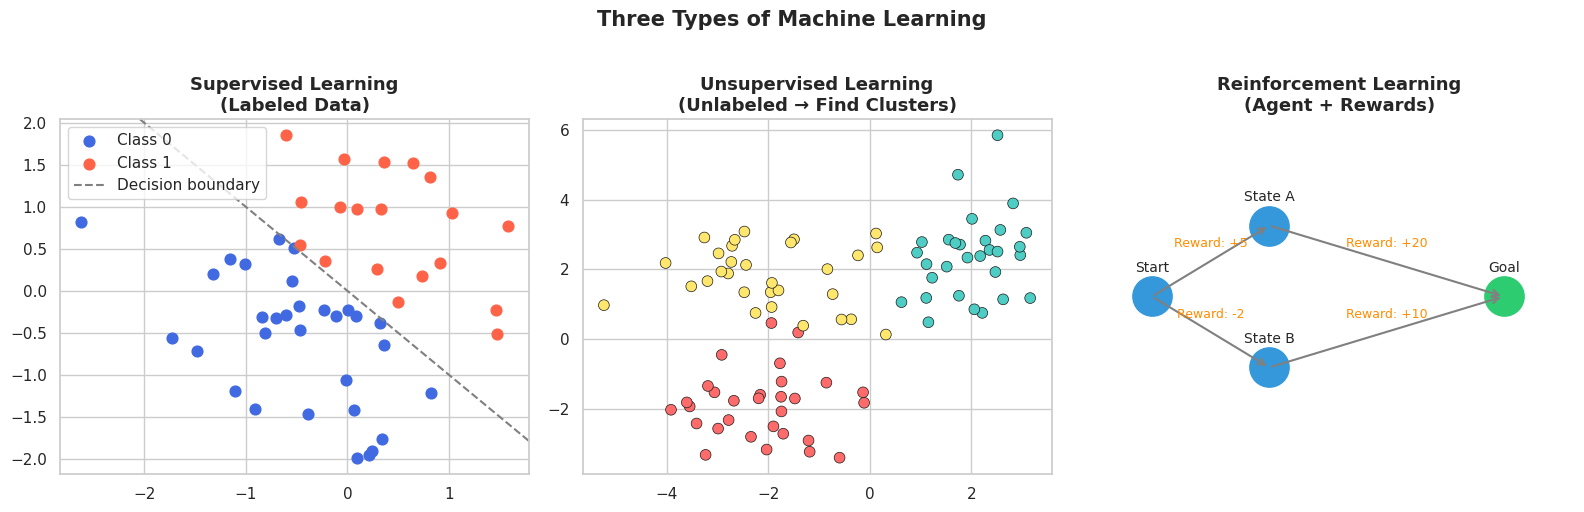

In [2]:
# Visualizing the 3 main types of ML
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Supervised Learning ---
ax = axes[0]
X_sup = np.random.randn(50, 2)
y_sup = (X_sup[:, 0] + X_sup[:, 1] > 0).astype(int)
ax.scatter(X_sup[y_sup==0, 0], X_sup[y_sup==0, 1], c='royalblue', label='Class 0', s=60)
ax.scatter(X_sup[y_sup==1, 0], X_sup[y_sup==1, 1], c='tomato', label='Class 1', s=60)
ax.axline((0,0), slope=(-1), color='gray', ls='--', lw=1.5, label='Decision boundary')
ax.set_title('Supervised Learning\n(Labeled Data)', fontsize=13, fontweight='bold')
ax.legend()

# --- Unsupervised Learning ---
ax = axes[1]
centers = [[-2, -2], [2, 2], [-2, 2]]
X_uns = np.vstack([np.random.randn(30, 2) + c for c in centers])
colors_uns = ['#FF6B6B']*30 + ['#4ECDC4']*30 + ['#FFE66D']*30
ax.scatter(X_uns[:, 0], X_uns[:, 1], c=colors_uns, s=60, edgecolors='k', lw=0.5)
ax.set_title('Unsupervised Learning\n(Unlabeled → Find Clusters)', fontsize=13, fontweight='bold')

# --- Reinforcement Learning ---
ax = axes[2]
states = ['Start', 'State A', 'State B', 'Goal']
positions = [(0.1,0.5), (0.35,0.7), (0.35,0.3), (0.85,0.5)]
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
for i, (s, p) in enumerate(zip(states, positions)):
    color = '#2ecc71' if s == 'Goal' else '#3498db'
    ax.scatter(*p, s=800, c=color, zorder=3)
    ax.text(p[0], p[1]+0.07, s, ha='center', fontsize=10)
arrows = [(0,1),(0,2),(1,3),(2,3)]
labels = ['+5','-2','+20','+10']
for (i,j), lbl in zip(arrows, labels):
    ax.annotate('', xytext=positions[i], xy=positions[j],
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    mid = ((positions[i][0]+positions[j][0])/2, (positions[i][1]+positions[j][1])/2)
    ax.text(mid[0], mid[1]+0.04, f'Reward: {lbl}', ha='center', fontsize=9, color='darkorange')
ax.set_title('Reinforcement Learning\n(Agent + Rewards)', fontsize=13, fontweight='bold')
ax.axis('off')

plt.suptitle('Three Types of Machine Learning', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🔄 3. The ML Workflow

```
1. Define Problem
      ↓
2. Collect Data
      ↓
3. Explore Data (EDA)
      ↓
4. Preprocess Data (Clean, Encode, Scale)
      ↓
5. Split Data (Train / Test)
      ↓
6. Train Model
      ↓
7. Evaluate Model
      ↓
8. Tune & Deploy
```

## 🔬 4. Introduction to Scikit-learn

Scikit-learn is the most popular **ML library in Python**. It provides:
- Simple and consistent API: `fit()`, `predict()`, `score()`
- Algorithms for classification, regression, clustering
- Tools for model evaluation and preprocessing

In [3]:
# Exploring a built-in dataset from sklearn
from sklearn.datasets import load_iris

iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print('Shape:', df_iris.shape)
print('\nFirst 5 rows:')
df_iris.head()

Shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Quick statistical summary
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


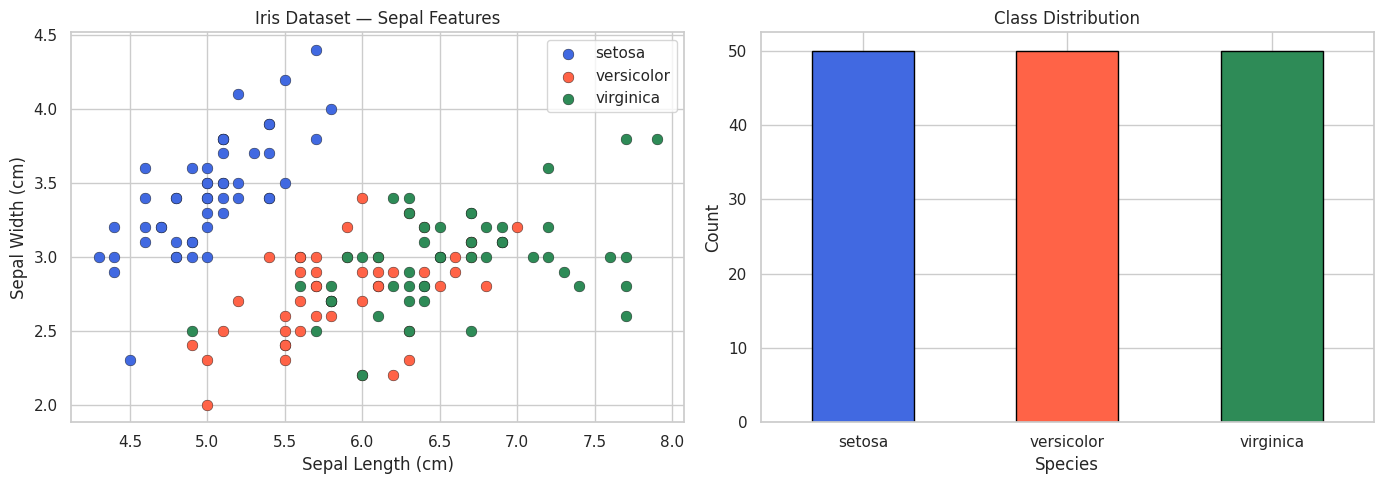

In [5]:
# Visualize the dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pairplot-style scatter
for species, color in zip(iris.target_names, ['royalblue', 'tomato', 'seagreen']):
    subset = df_iris[df_iris['species'] == species]
    axes[0].scatter(subset['sepal length (cm)'], subset['sepal width (cm)'],
                    label=species, c=color, s=60, edgecolors='k', lw=0.3)
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].set_title('Iris Dataset — Sepal Features')
axes[0].legend()

# Species count
df_iris['species'].value_counts().plot(kind='bar', ax=axes[1],
                                        color=['royalblue', 'tomato', 'seagreen'],
                                        edgecolor='black')
axes[1].set_title('Class Distribution')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 5. Hands-on: Simple Linear Regression

**Problem:** Predict a student's exam score based on hours studied.

**Algorithm:** Linear Regression — finds the best-fit line: `y = mx + b`

In [6]:
# ── Step 1: Create synthetic dataset ──
np.random.seed(0)
hours_studied = np.linspace(1, 10, 50) + np.random.normal(0, 0.5, 50)
exam_scores   = 5 * hours_studied + 30 + np.random.normal(0, 5, 50)

df_lr = pd.DataFrame({'Hours_Studied': hours_studied, 'Exam_Score': exam_scores})
print('Dataset preview:')
df_lr.head(10)

Dataset preview:


,Hours_Studied,Exam_Score
0,1.882026,34.932798
1,1.383752,38.853273
2,1.856716,36.729554
3,2.671467,37.454174
4,2.668473,43.201453
5,1.429728,39.290301
6,2.577085,43.218011
7,2.210036,42.562538
8,2.417778,38.917281
9,2.858360,42.478097


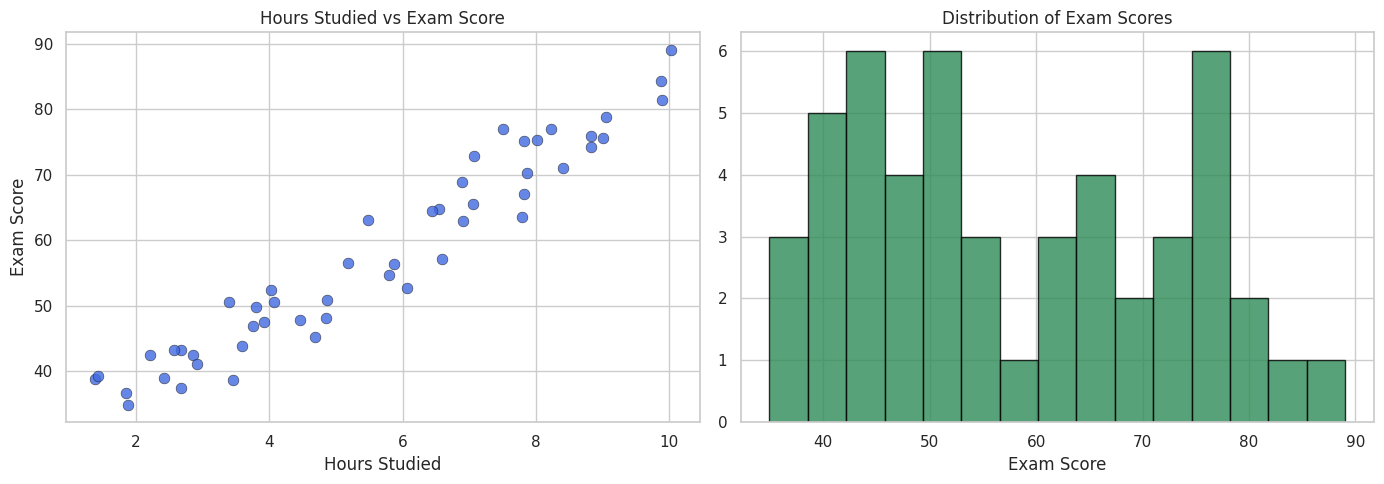

Correlation: 0.9639


In [7]:
# ── Step 2: Explore data ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_lr['Hours_Studied'], df_lr['Exam_Score'],
                color='royalblue', edgecolors='k', lw=0.4, s=60, alpha=0.8)
axes[0].set_xlabel('Hours Studied')
axes[0].set_ylabel('Exam Score')
axes[0].set_title('Hours Studied vs Exam Score')

axes[1].hist(df_lr['Exam_Score'], bins=15, color='seagreen', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Exam Score')
axes[1].set_title('Distribution of Exam Scores')

plt.tight_layout()
plt.show()

print(f'Correlation: {df_lr.corr()["Exam_Score"]["Hours_Studied"]:.4f}')

In [8]:
# ── Step 3: Prepare features & target ──
X = df_lr[['Hours_Studied']]   # 2D array required by sklearn
y = df_lr['Exam_Score']

# ── Step 4: Train-Test Split ──
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 40
Testing  samples : 10


In [9]:
# ── Step 5: Train the model ──
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

print(f'Model Coefficient (slope)    : {model_lr.coef_[0]:.4f}')
print(f'Model Intercept              : {model_lr.intercept_:.4f}')
print(f'\nEquation: Exam Score = {model_lr.coef_[0]:.2f} × Hours + {model_lr.intercept_:.2f}')

Model Coefficient (slope)    : 5.6857
Model Intercept              : 26.3427

Equation: Exam Score = 5.69 × Hours + 26.34


In [10]:
# ── Step 6: Predict & Evaluate ──
y_pred = model_lr.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('📊 Model Evaluation Metrics:')
print(f'  MSE  (Mean Squared Error)       : {mse:.4f}')
print(f'  RMSE (Root Mean Squared Error)  : {rmse:.4f}')
print(f'  R²   (Coefficient of Determination): {r2:.4f}')
print(f'\n  R² = {r2:.2%} variance in exam scores explained by hours studied.')

📊 Model Evaluation Metrics:
  MSE  (Mean Squared Error)       : 16.0438
  RMSE (Root Mean Squared Error)  : 4.0055
  R²   (Coefficient of Determination): 0.8983

  R² = 89.83% variance in exam scores explained by hours studied.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


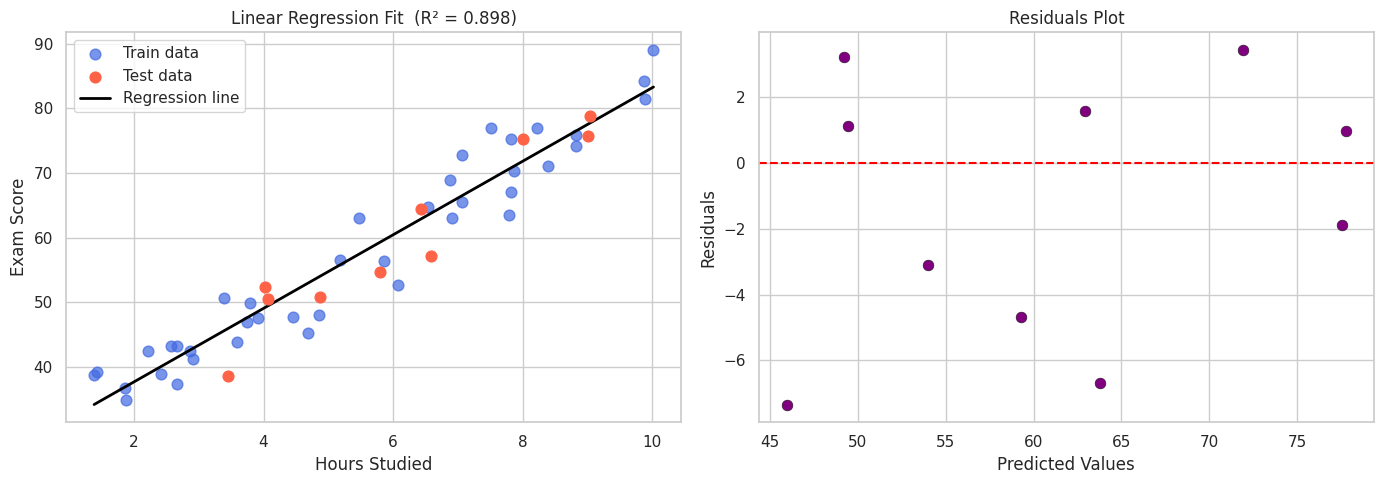

In [11]:
# ── Step 7: Visualize Results ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression line
X_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
y_line = model_lr.predict(X_line)

axes[0].scatter(X_train, y_train, color='royalblue', label='Train data', s=60, alpha=0.7)
axes[0].scatter(X_test, y_test, color='tomato', label='Test data', s=60, zorder=3)
axes[0].plot(X_line, y_line, color='black', lw=2, label='Regression line')
axes[0].set_xlabel('Hours Studied')
axes[0].set_ylabel('Exam Score')
axes[0].set_title(f'Linear Regression Fit  (R² = {r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='purple', edgecolors='k', lw=0.4, s=60)
axes[1].axhline(0, color='red', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()

In [12]:
# ── Step 8: Make a Prediction ──
hours_input = 7.5
predicted_score = model_lr.predict([[hours_input]])[0]
print(f'🎯 If a student studies for {hours_input} hours,')
print(f'   predicted exam score = {predicted_score:.2f}')

🎯 If a student studies for 7.5 hours,
   predicted exam score = 68.99


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
# 📅 Supervised & Unsupervised Learning
---

## 🔀 6. Train-Test Split (Deep Dive)

Splitting data prevents **overfitting** — when a model memorizes training data but fails on new data.

In [13]:
# Load the Breast Cancer dataset for classification tasks
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = cancer.target

print('Dataset shape  :', X_cancer.shape)
print('Target classes :', cancer.target_names)
print('Class counts   :', dict(zip(cancer.target_names, np.bincount(y_cancer))))

Dataset shape  : (569, 30)
Target classes : ['malignant' 'benign']
Class counts   : {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


Training set   : (455, 30)
Testing  set   : (114, 30)


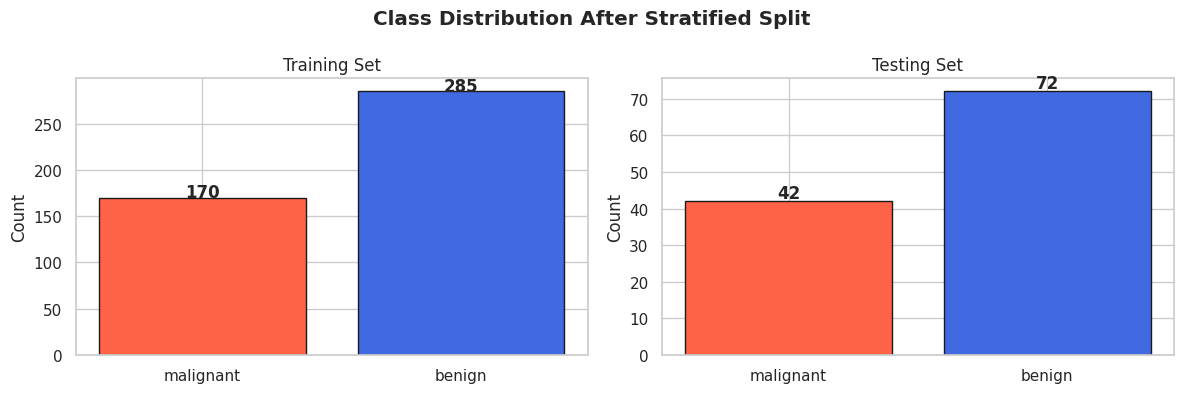

In [14]:
# Stratified train-test split — preserves class proportions
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer,
    test_size=0.2,
    random_state=42,
    stratify=y_cancer   # <-- ensures class balance in both splits
)

print('Training set   :', X_train_c.shape)
print('Testing  set   :', X_test_c.shape)

# Visualize split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in zip(axes,
    [np.bincount(y_train_c), np.bincount(y_test_c)],
    ['Training Set', 'Testing Set']):
    ax.bar(cancer.target_names, counts, color=['tomato','royalblue'], edgecolor='k')
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts):
        ax.text(i, v+1, str(v), ha='center', fontweight='bold')
plt.suptitle('Class Distribution After Stratified Split', fontweight='bold')
plt.tight_layout()
plt.show()

## 🔬 7. Feature Selection Basics

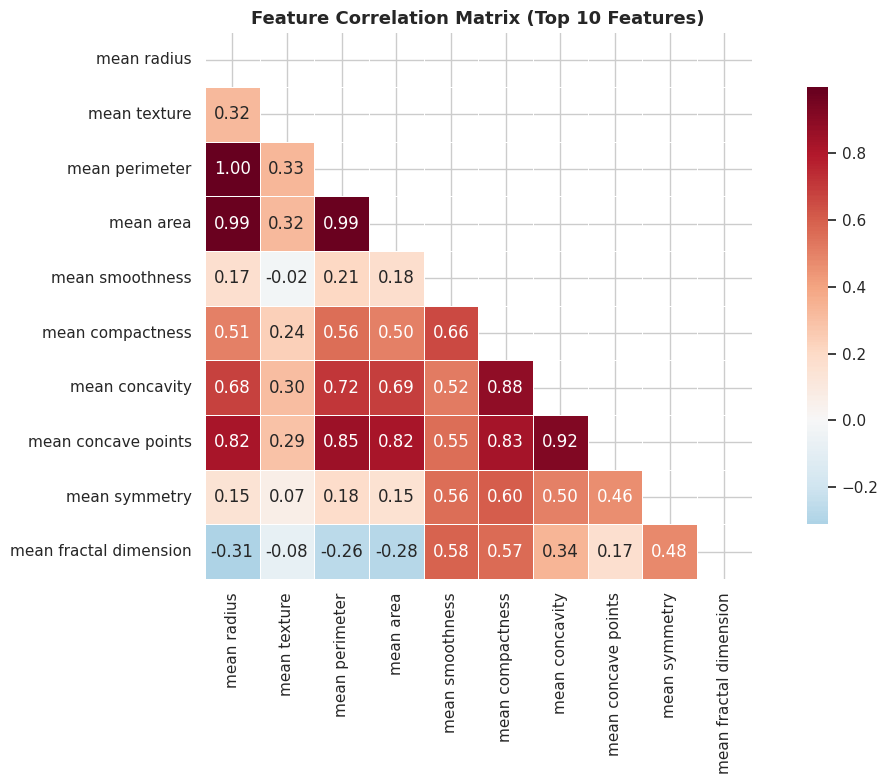

In [15]:
# Method 1: Correlation Heatmap (visual feature selection)
top_features = X_cancer.columns[:10]  # first 10 features for readability
corr_matrix = X_cancer[top_features].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Top 10 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

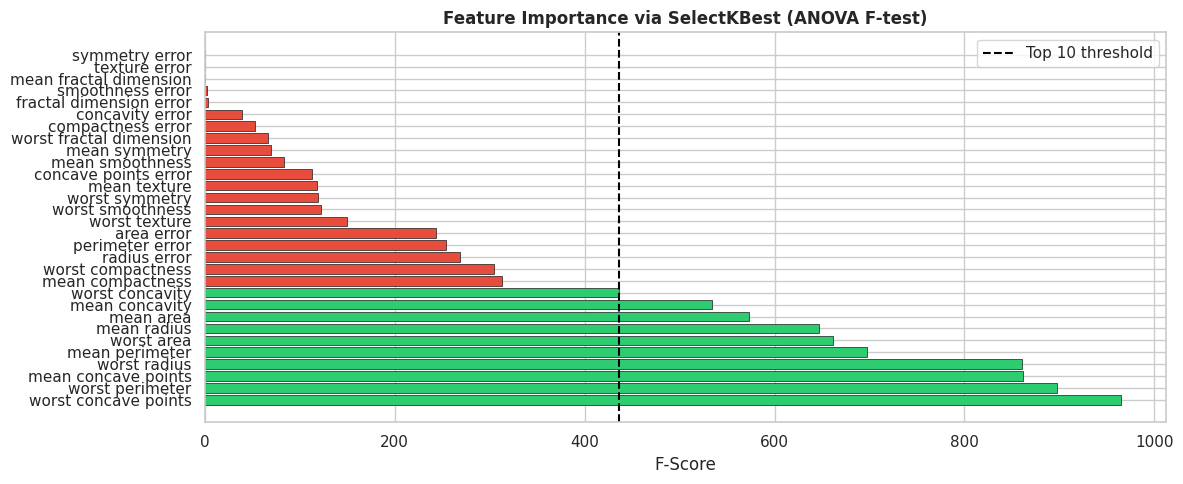


Top 10 selected features:
['mean radius' 'mean perimeter' 'mean area' 'mean concavity'
 'mean concave points' 'worst radius' 'worst perimeter' 'worst area'
 'worst concavity' 'worst concave points']


In [16]:
# Method 2: SelectKBest — statistical test to pick top features
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_cancer, y_cancer)

feature_scores = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Score'  : selector.scores_
}).sort_values('Score', ascending=False)

plt.figure(figsize=(12, 5))
colors = ['#2ecc71' if s else '#e74c3c' for s in selector.get_support()]
plt.barh(feature_scores['Feature'], feature_scores['Score'],
         color=[colors[i] for i in feature_scores.index], edgecolor='k', lw=0.5)
plt.axvline(selector.scores_[np.argsort(selector.scores_)[-10]], color='black',
            ls='--', lw=1.5, label='Top 10 threshold')
plt.xlabel('F-Score')
plt.title('Feature Importance via SelectKBest (ANOVA F-test)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('\nTop 10 selected features:')
print(cancer.feature_names[selector.get_support()])

In [17]:
# Apply feature selection
X_train_sel = selector.transform(X_train_c)
X_test_sel  = selector.transform(X_test_c)

print(f'Original features : {X_train_c.shape[1]}')
print(f'Selected features : {X_train_sel.shape[1]}')

Original features : 30
Selected features : 10


## 🔮 8. Logistic Regression (Classification)

In [18]:
# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_c)

y_pred_lr = log_reg.predict(X_test_scaled)

print('📊 Logistic Regression Results:')
print(f'  Accuracy : {accuracy_score(y_test_c, y_pred_lr):.4f}')
print()
print(classification_report(y_test_c, y_pred_lr, target_names=cancer.target_names))

📊 Logistic Regression Results:
  Accuracy : 0.9474

              precision    recall  f1-score   support

   malignant       0.91      0.95      0.93        42
      benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



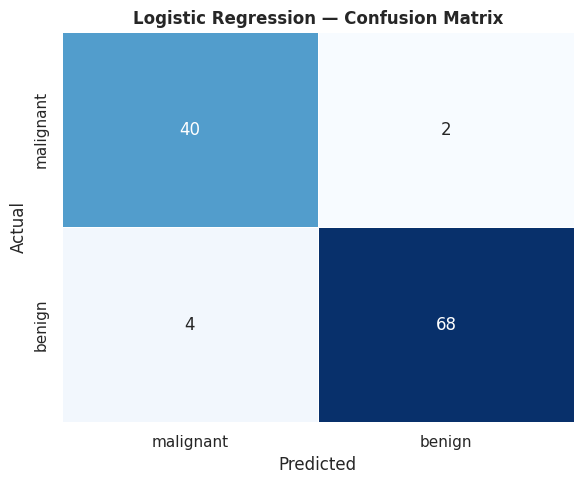

In [19]:
# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test_c, y_pred_lr, cancer.target_names,
                      'Logistic Regression — Confusion Matrix')

## 🏘️ 9. K-Nearest Neighbors (KNN)

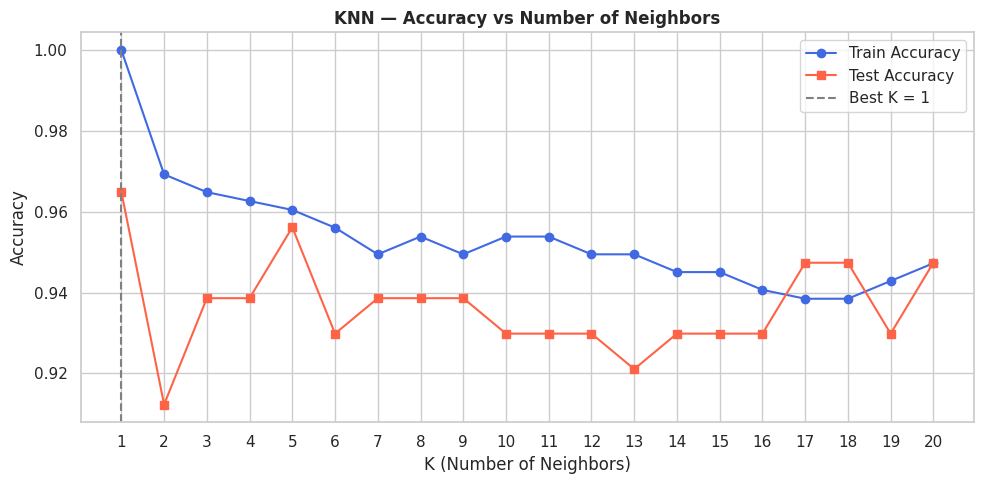

Best K = 1, Test Accuracy = 0.9649


In [20]:
# Train KNN with different K values and compare
k_values  = range(1, 21)
train_acc = []
test_acc  = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train_c)
    train_acc.append(accuracy_score(y_train_c, knn.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test_c, knn.predict(X_test_scaled)))

# Plot accuracy vs K
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_acc, 'o-', label='Train Accuracy', color='royalblue')
plt.plot(k_values, test_acc,  's-', label='Test Accuracy',  color='tomato')
best_k = k_values[np.argmax(test_acc)]
plt.axvline(best_k, color='gray', ls='--', lw=1.5, label=f'Best K = {best_k}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs Number of Neighbors', fontweight='bold')
plt.legend()
plt.xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Best K = {best_k}, Test Accuracy = {max(test_acc):.4f}')

📊 KNN (K=1) Results:
  Accuracy : 0.9649

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



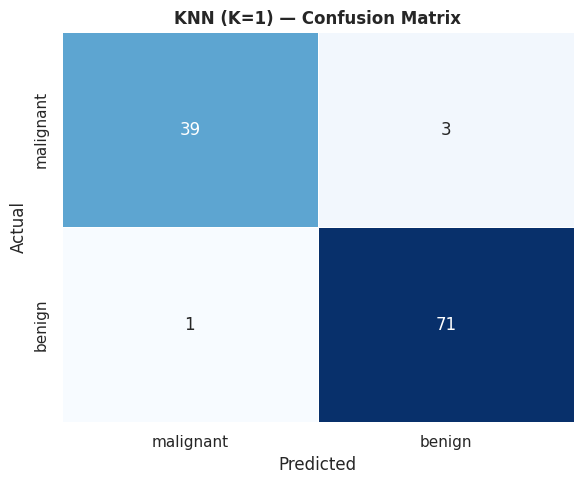

In [21]:
# Train best KNN model
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train_c)
y_pred_knn = best_knn.predict(X_test_scaled)

print(f'📊 KNN (K={best_k}) Results:')
print(f'  Accuracy : {accuracy_score(y_test_c, y_pred_knn):.4f}')
print()
print(classification_report(y_test_c, y_pred_knn, target_names=cancer.target_names))

plot_confusion_matrix(y_test_c, y_pred_knn, cancer.target_names,
                      f'KNN (K={best_k}) — Confusion Matrix')

## 📊 10. K-Means Clustering (Unsupervised Learning)

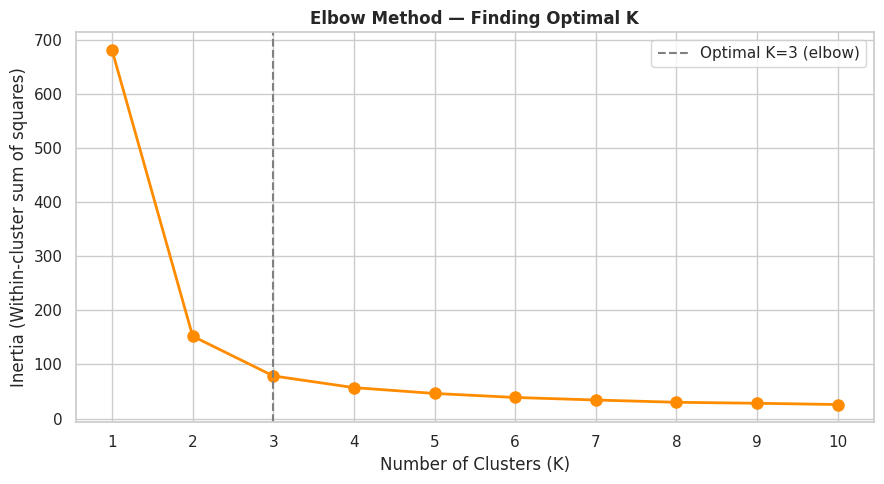

In [22]:
# Use Iris dataset for clustering demo
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris()
X_iris = iris.data

# Step 1: Elbow Method — finding optimal K
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_iris)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, 'o-', color='darkorange', lw=2, ms=8)
plt.axvline(3, color='gray', ls='--', lw=1.5, label='Optimal K=3 (elbow)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method — Finding Optimal K', fontweight='bold')
plt.legend()
plt.xticks(K_range)
plt.tight_layout()
plt.show()

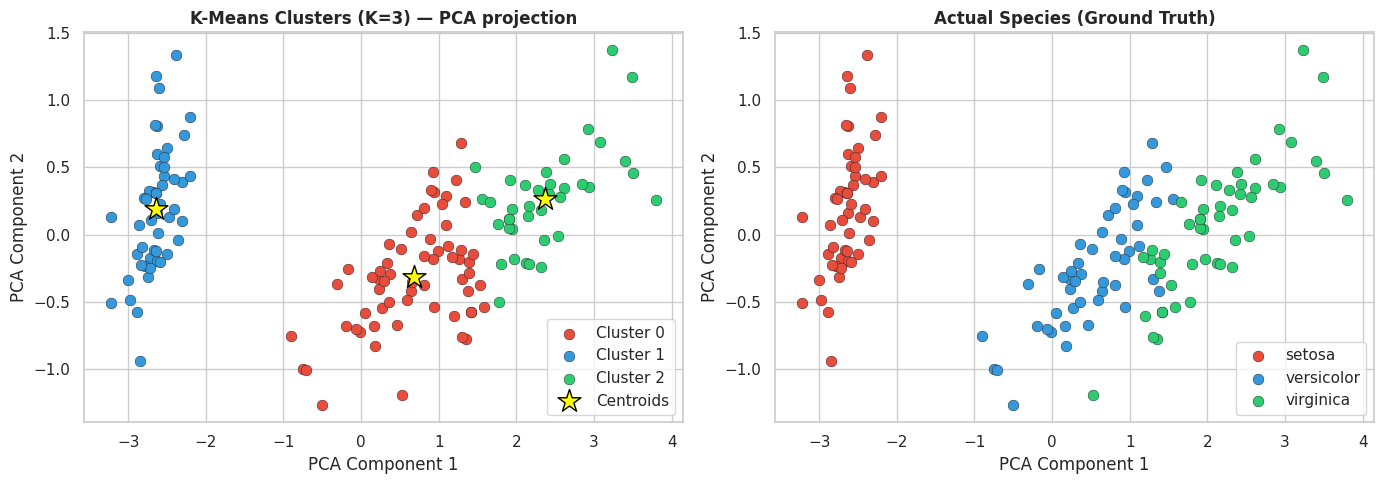

In [23]:
# Step 2: Train K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_iris)

# Step 3: Reduce to 2D with PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means clusters
colors_km = ['#E74C3C', '#3498DB', '#2ECC71']
for i, c in enumerate(colors_km):
    mask = cluster_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=c, label=f'Cluster {i}', s=60, edgecolors='k', lw=0.3)
# Plot centroids
centers_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1],
                c='yellow', marker='*', s=300, edgecolors='black', lw=1, zorder=5, label='Centroids')
axes[0].set_title('K-Means Clusters (K=3) — PCA projection', fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

# Ground truth labels
for i, (species, c) in enumerate(zip(iris.target_names, colors_km)):
    mask = iris.target == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=c, label=species, s=60, edgecolors='k', lw=0.3)
axes[1].set_title('Actual Species (Ground Truth)', fontweight='bold')
axes[1].legend()
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

In [24]:
# Evaluate clustering (using ground truth for comparison)
from sklearn.metrics import adjusted_rand_score, silhouette_score

ari = adjusted_rand_score(iris.target, cluster_labels)
sil = silhouette_score(X_iris, cluster_labels)

print('📊 K-Means Clustering Evaluation:')
print(f'  Adjusted Rand Index (ARI)  : {ari:.4f}  (1.0 = perfect)')
print(f'  Silhouette Score           : {sil:.4f}  (higher is better, max=1)')

📊 K-Means Clustering Evaluation:
  Adjusted Rand Index (ARI)  : 0.7302  (1.0 = perfect)
  Silhouette Score           : 0.5528  (higher is better, max=1)


## 🏆 11. Model Comparison Summary

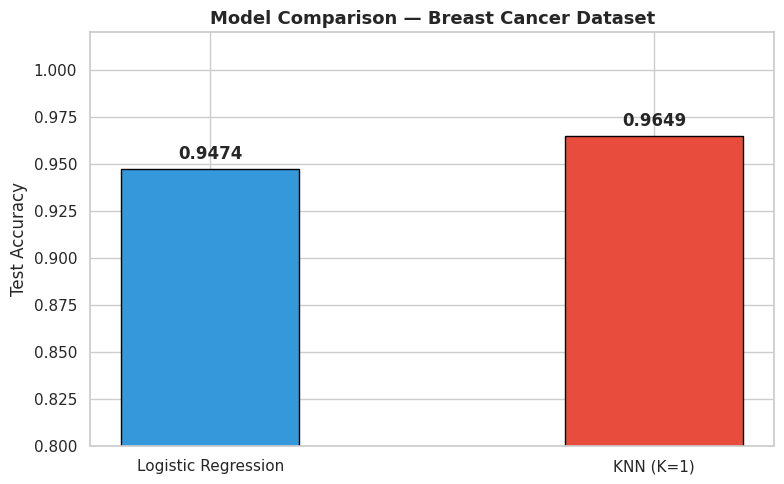


📋 Summary Table:
              Model        Accuracy       Type Scaling needed?
Logistic Regression 0.9474 (94.74%) Supervised             Yes
          KNN (K=1) 0.9649 (96.49%) Supervised             Yes


In [25]:
# Compare all classification models side-by-side
results = {
    'Logistic Regression' : accuracy_score(y_test_c, y_pred_lr),
    f'KNN (K={best_k})'   : accuracy_score(y_test_c, y_pred_knn),
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(results.keys(), results.values(),
              color=['#3498db', '#e74c3c'], edgecolor='black', width=0.4)

for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Model Comparison — Breast Cancer Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📋 Summary Table:')
summary_df = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Accuracy' : [f'{v:.4f} ({v*100:.2f}%)' for v in results.values()],
    'Type'     : ['Supervised', 'Supervised'],
    'Scaling needed?' : ['Yes', 'Yes']
})
print(summary_df.to_string(index=False))

---
## 🎯 12. Practice Exercises

Try these on your own:

### Day 4 Exercises:
1. Load the `load_diabetes()` dataset from sklearn and build a linear regression model
2. Try adding more features (multiple linear regression) and compare R² scores
3. Plot the learning curve as training size changes

### Day 5 Exercises:
1. Try KNN on the Iris dataset — what accuracy do you get?
2. Apply K-Means on the breast cancer dataset with K=2, does it separate malignant/benign?
3. Try different `test_size` values (0.1, 0.3, 0.4) and observe how accuracy changes

---

## 📚 Key Takeaways

| Concept | Key Point |
|---|---|
| Linear Regression | Predicts continuous values using a line `y = mx + b` |
| Logistic Regression | Classifies data using probability (sigmoid function) |
| KNN | Classifies based on K nearest neighbors — no training, lazy learner |
| K-Means | Groups unlabeled data into K clusters based on distance |
| Train-Test Split | Prevents overfitting; stratify for balanced classes |
| Feature Selection | Removes irrelevant/redundant features to improve model |
| StandardScaler | Centers features (mean=0, std=1) — essential for KNN, LR |

---
*Happy Learning!*

## 🎯 12. Practice Exercises: Diabetes Dataset

### Task 1: Simple Linear Regression on Diabetes Dataset

Diabetes dataset loaded successfully!
Features shape: (442, 10)
Target shape: (442,)

Simple Linear Regression (using 'bmi'):
  R² Score: 0.2334


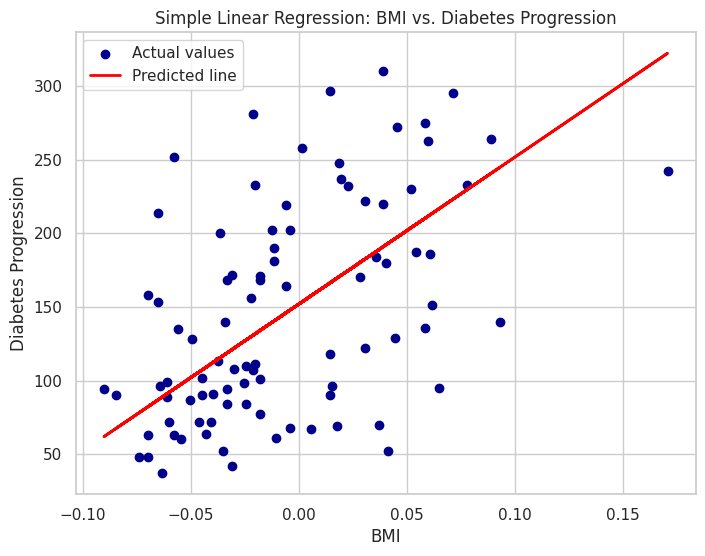

In [28]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Load the diabetes dataset
diabetes = load_diabetes()
X_d = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_d = diabetes.target

print("Diabetes dataset loaded successfully!")
print(f"Features shape: {X_d.shape}")
print(f"Target shape: {y_d.shape}")

# --- Simple Linear Regression (using one feature) ---

# Choose one feature, e.g., 'bmi' for simple linear regression
X_simple = X_d[['bmi']]

# Split the data into training and testing sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_d, test_size=0.2, random_state=42
)

# Train the Linear Regression model
model_simple_lr = LinearRegression()
model_simple_lr.fit(X_train_s, y_train_s)

# Make predictions
y_pred_s = model_simple_lr.predict(X_test_s)

# Evaluate the model
r2_simple = r2_score(y_test_s, y_pred_s)

print(f"\nSimple Linear Regression (using 'bmi'):")
print(f"  R² Score: {r2_simple:.4f}")

# Visualize the simple linear regression
plt.figure(figsize=(8, 6))
plt.scatter(X_test_s, y_test_s, color='darkblue', label='Actual values')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Predicted line')
plt.xlabel('BMI')
plt.ylabel('Diabetes Progression')
plt.title('Simple Linear Regression: BMI vs. Diabetes Progression')
plt.legend()
plt.grid(True)
plt.show()

### Day 5 Exercises:

### Task 1: Try KNN on the Iris dataset — what accuracy do you get?

### Task 2: Apply K-Means on the breast cancer dataset with K=2, does it separate malignant/benign?

Breast Cancer dataset loaded successfully!
Features shape: (569, 30)
Target classes: ['malignant' 'benign']

K-Means (K=2) on Breast Cancer Dataset:
  Adjusted Rand Index (ARI): 0.6536
  Silhouette Score: 0.3434

Counts in Cluster 0 (actual labels): [ 36 339] (0=malignant, 1=benign)
Counts in Cluster 1 (actual labels): [176  18] (0=malignant, 1=benign)


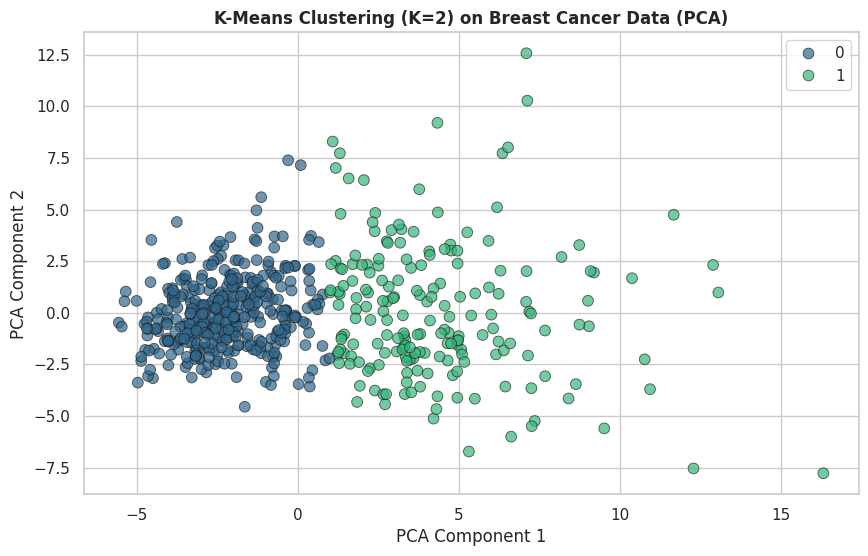

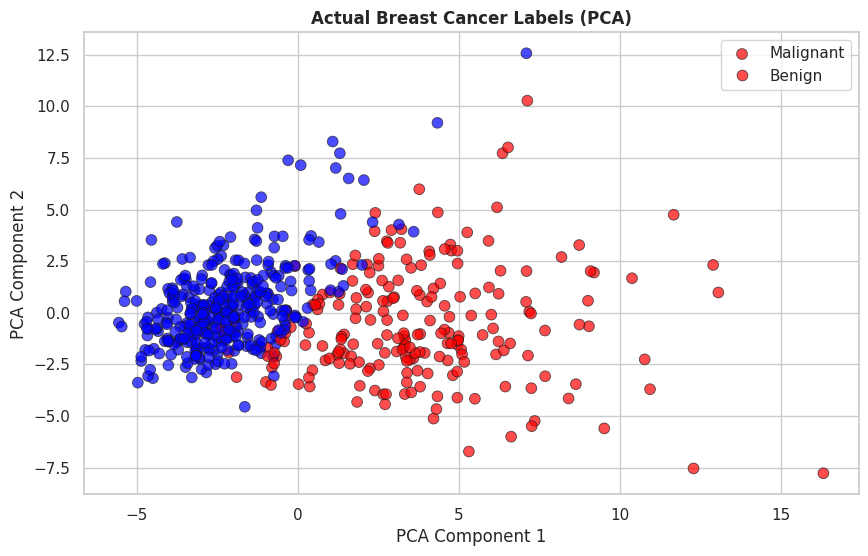


Based on the ARI score and cluster distribution, K-Means does a reasonably good job of separating the malignant/benign cases, even though it is an unsupervised algorithm.


In [30]:
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the breast cancer dataset
cancer = load_breast_cancer()
X_cancer_data = cancer.data
y_cancer_labels = cancer.target

print("Breast Cancer dataset loaded successfully!")
print(f"Features shape: {X_cancer_data.shape}")
print(f"Target classes: {cancer.target_names}")

# Scale the data before applying K-Means
scaler_bc = StandardScaler()
X_cancer_scaled = scaler_bc.fit_transform(X_cancer_data)

# Apply K-Means with K=2
kmeans_bc = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels_bc = kmeans_bc.fit_predict(X_cancer_scaled)

# Evaluate clustering using Adjusted Rand Index (ARI) and Silhouette Score
# Note: ARI compares clustering to ground truth, Silhouette Score evaluates cluster density/separation
ari_bc = adjusted_rand_score(y_cancer_labels, cluster_labels_bc)
sil_bc = silhouette_score(X_cancer_scaled, cluster_labels_bc)

print(f"\nK-Means (K=2) on Breast Cancer Dataset:")
print(f"  Adjusted Rand Index (ARI): {ari_bc:.4f}")
print(f"  Silhouette Score: {sil_bc:.4f}")

# To check if it separates malignant/benign, we can map cluster labels to actual labels
# K-Means labels are arbitrary (0 or 1), so we need to map them to 'malignant'/'benign'
# Let's assume cluster 0 corresponds to one class and cluster 1 to the other
# We'll see which cluster has more of a certain class

cluster_0_counts = np.bincount(y_cancer_labels[cluster_labels_bc == 0])
cluster_1_counts = np.bincount(y_cancer_labels[cluster_labels_bc == 1])

print(f"\nCounts in Cluster 0 (actual labels): {cluster_0_counts} (0=malignant, 1=benign)")
print(f"Counts in Cluster 1 (actual labels): {cluster_1_counts} (0=malignant, 1=benign)")

# Determine which cluster best represents 'malignant' (0) and 'benign' (1)
# If cluster_0 has more 0s, and cluster_1 has more 1s, then ARI will be high
# If cluster_0 has more 1s, and cluster_1 has more 0s, ARI will still be high (due to label permutation)

# Visualize the clusters using PCA for dimensionality reduction
pca_bc = PCA(n_components=2)
X_pca_bc = pca_bc.fit_transform(X_cancer_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca_bc[:, 0],
    y=X_pca_bc[:, 1],
    hue=cluster_labels_bc,
    palette='viridis',
    s=60,
    alpha=0.7,
    edgecolor='k',
    legend='full'
)
plt.title('K-Means Clustering (K=2) on Breast Cancer Data (PCA)', fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca_bc[:, 0],
    y=X_pca_bc[:, 1],
    hue=y_cancer_labels,
    palette={0: 'red', 1: 'blue'},
    s=60,
    alpha=0.7,
    edgecolor='k',
    legend='full'
)
plt.title('Actual Breast Cancer Labels (PCA)', fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(labels=['Malignant', 'Benign'])
plt.show()

print("\nBased on the ARI score and cluster distribution, K-Means does a reasonably good job of separating the malignant/benign cases, even though it is an unsupervised algorithm.")

In [29]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Load the Iris dataset
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target

print("Iris dataset loaded successfully!")
print(f"Features shape: {X_iris.shape}")
print(f"Target shape: {y_iris.shape}")

# Split the data into training and testing sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Scale the features (important for KNN)
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled  = scaler_iris.transform(X_test_iris)

# Train a KNN model (using k=5 as a starting point)
knn_iris = KNeighborsClassifier(n_neighbors=5)
knn_iris.fit(X_train_iris_scaled, y_train_iris)

# Make predictions
y_pred_iris = knn_iris.predict(X_test_iris_scaled)

# Evaluate the model
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)

print(f"\nKNN (k=5) on Iris Dataset Accuracy: {accuracy_iris:.4f}")

Iris dataset loaded successfully!
Features shape: (150, 4)
Target shape: (150,)

KNN (k=5) on Iris Dataset Accuracy: 0.9111
